In [2]:
import pandas as pd
URLCSV = "https://docs.google.com/spreadsheets/d/1eI8uGEHNUZptv2wbNQdXLQTwQndGUstGFmtZ4VWNqWY/export?format=csv"
dane = pd.read_csv(URLCSV)
print(dane.head())

   LP                                              rzuty  fake  score  \
0   1  OOOOROORRRRRRORORORROOOORORRRRORROOOROORRRROOO...     1    565   
1   2  OOROOORRORRROOROROORROROOOORORROOORRORRROROORO...     1    408   
2   3  ORORORORRORORORORRORORRROOOROOROOOORRRROOROORO...     1    513   
3   4  OORORROOORRROOORROOOORRROOORRORROORRORRORRORRR...     1    333   
4   5  OORORRROROROOORRORRORROOORORROOORORORROORROOOR...     1     88   

   pierwszy_O  liczba_serii  liczba_O  max_seria  runtest_z      sd10  \
0           1            49        49          6  -0.297627  0.128668   
1           1            57        53          5   1.145949  0.082327   
2           1            56        52          9   0.922152  0.139841   
3           1            53        49          4   0.305671  0.087560   
4           1            64        48          3   2.532898  0.078881   

   sum_2max  sum_3max  sum_4max  sum_5max  sum_6max  sum_7max  count_1  
0        11        15        19        23        

In [3]:
import numpy as np
print(np.sum(dane['fake']==1))
print(np.sum(dane['fake']==0))

30
1000


In [22]:
import pandas as pd
dane['max_seria2'] = dane['max_seria']
dane.loc[dane['max_seria'] > 6, 'max_seria2'] = 7
dane['max_seria2'] = dane['max_seria2'].astype(str)
dane['fake'] = dane['fake'].astype(str)
pd.crosstab(dane['fake'], dane['max_seria2'])

max_seria2,3,4,5,6,7
fake,,,,,
0,0,31,167,289,513
1,5,11,6,3,5


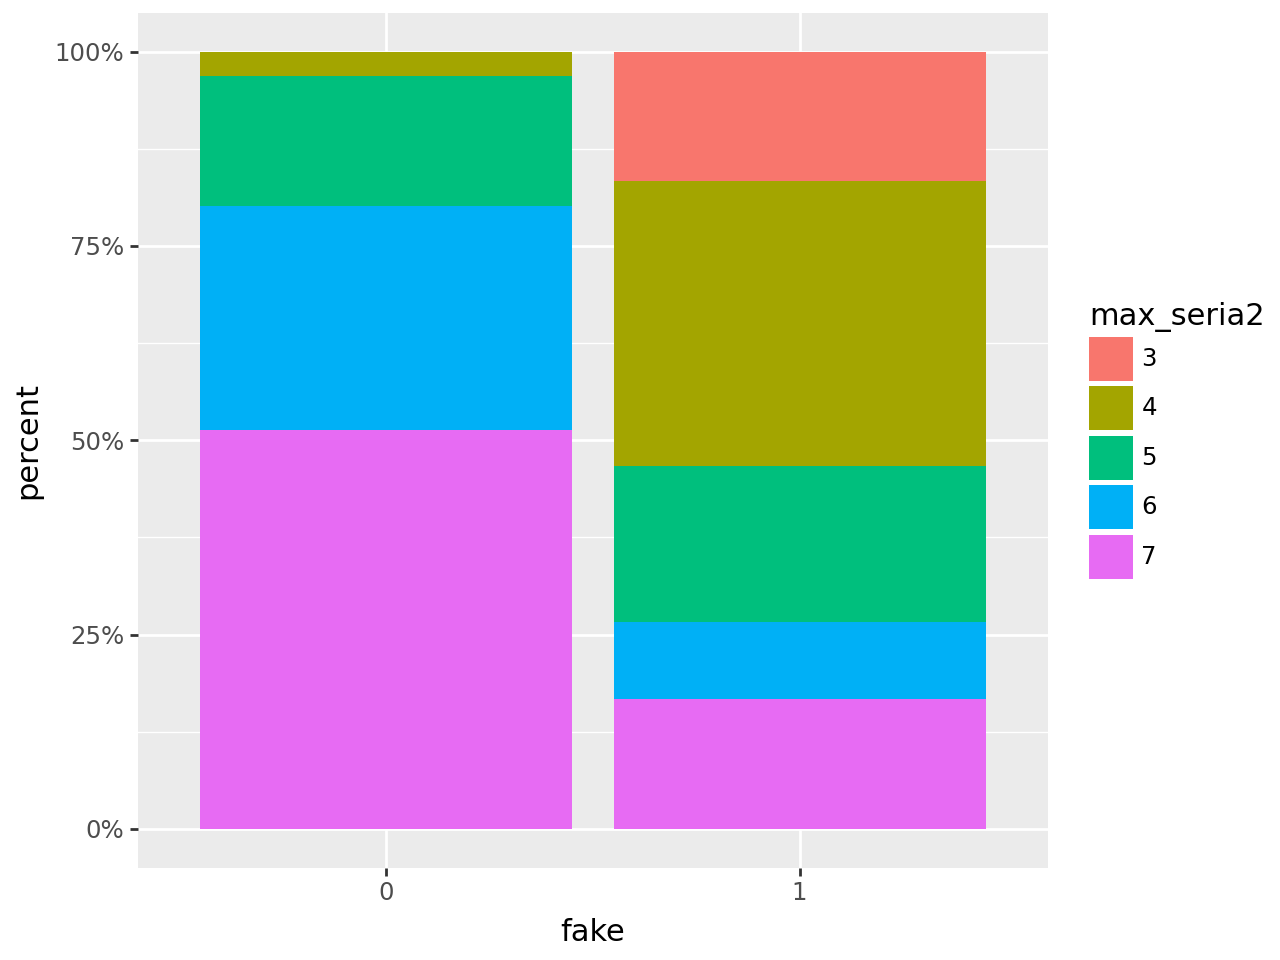

In [25]:
#!pip install plotnine
from plotnine import *

(
    ggplot(dane, aes(x='fake', fill='max_seria2'))
    + geom_bar(position='fill')
    + scale_y_continuous(labels=lambda l: ["{:.0%}".format(v) for v in l])
    + labs(x='fake', y='percent')
)

Przykłady prostych testów statystycznych w Pythonie może znaleźć tutaj:
https://bookdown.org/blazej_kochanski/statystyka2/szablony-dodatek.html




In [29]:
import scipy.stats as stats
m = pd.crosstab(dane['fake'], dane['max_seria2'])

test_chi2 = stats.chi2_contingency(m)
test_chi2

Chi2ContingencyResult(statistic=np.float64(257.9522802975311), pvalue=np.float64(1.2596145597520978e-54), dof=4, expected_freq=array([[4.85436893e+00, 4.07766990e+01, 1.67961165e+02, 2.83495146e+02,
        5.02912621e+02],
       [1.45631068e-01, 1.22330097e+00, 5.03883495e+00, 8.50485437e+00,
        1.50873786e+01]]))

Test chi-kwadrat (p-value = 0,0000000000000000000000000000000000...00001259) pokazuje, że otrzymanie takiej jak na wykresie (albo większej) dysproporcji jest praktycznie niemożliwe do uzyskania przypadkiem. 
